# 03 — Exploratory Data Analysis (Master Dataset)

This notebook analyzes the consolidated `master_df` produced by the data-cleaning workflow. The master dataset is joined at a detailed grain, so all KPI calculations first reconstruct the correct entity-level tables to prevent join multiplication from overstating totals.

## Setup and data loading

In [23]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')

PROJECT_ROOT = Path('..')
MASTER_PATH = PROJECT_ROOT / 'data' / 'processed' / 'master_df.csv'
assert MASTER_PATH.exists(), f'Master dataset not found: {MASTER_PATH.resolve()}'

DATE_COLUMNS = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp',
]
CATEGORY_COLUMNS = [
    'order_status', 'customer_gender', 'customer_state', 'customer_segment',
    'product_category_name', 'payment_type', 'seller_state',
]

master_df = pd.read_csv(
    MASTER_PATH,
    parse_dates=DATE_COLUMNS,
    dtype={column: 'category' for column in CATEGORY_COLUMNS},
    low_memory=False,
)

for column in master_df.select_dtypes(include=['float64']).columns:
    master_df[column] = pd.to_numeric(master_df[column], downcast='float')
for column in master_df.select_dtypes(include=['int64']).columns:
    master_df[column] = pd.to_numeric(master_df[column], downcast='integer')

print(f'Loaded {master_df.shape[0]:,} rows × {master_df.shape[1]:,} columns')
print(f'Memory usage: {master_df.memory_usage(deep=True).sum() / 1024**3:.2f} GB')

Loaded 2,530,433 rows × 49 columns
Memory usage: 2.94 GB


## Dataset overview

In [24]:
print('\n================ DATASET INFO ================\n')
master_df.info()
print('\nDataset Shape:')
print(master_df.shape)

display(master_df.head())
display(master_df.isna().sum().sort_values(ascending=False).to_frame('missing_records'))
display(master_df.nunique(dropna=True).sort_values(ascending=False).to_frame('unique_values'))


================ DATASET INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530433 entries, 0 to 2530432
Data columns (total 49 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   order_id                       object        
 1   customer_id                    object        
 2   order_status                   category      
 3   order_purchase_timestamp       datetime64[ns]
 4   order_approved_at              datetime64[ns]
 5   order_delivered_carrier_date   datetime64[ns]
 6   order_delivered_customer_date  datetime64[ns]
 7   order_estimated_delivery_date  datetime64[ns]
 8   customer_unique_id             object        
 9   customer_name                  object        
 10  customer_gender                category      
 11  customer_age                   int8          
 12  customer_zip_code_prefix       int32         
 13  customer_city                  object        
 14  customer_state   

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_name,customer_gender,customer_age,customer_zip_code_prefix,customer_city,customer_state,customer_segment,order_item_id,product_id,seller_id,shipping_limit_date,price_x,freight_value,discount_rate,product_category_name,product_name,product_brand,product_weight_g,product_length_cm,product_height_cm,product_width_cm,cost,price_y,seller_company_name,seller_contact_name,seller_contact_gender,seller_contact_age,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,M,47,85037,Phoenix,AZ,Consumer,1,89804d82-33a1-4558-8fa2-9b0252a2a406,36c2b043-ccf4-4d9c-a0bb-4b8d28737fd7,2025-12-30 07:07:20,916.90,45.47,0.00,furniture,Nova Desk - Industrial,Nova,24130,108,10,13,395.24,916.90,Jones-Russell,Nicholas Thompson,M,18,90086,Los Angeles,CA,1,paypal,1,"2,084.01",NaN,NaN,NaN,NaN,NaT,NaT
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,M,47,85037,Phoenix,AZ,Consumer,2,ac10b78c-342e-4b50-9ea9-bddde7db2e79,09936504-415b-4f90-a5b8-ad15a5be67d0,2025-12-30 07:07:20,817.14,172.48,0.00,electronics,Vertex Smartwatch S468,Vertex,586,28,19,23,717.81,817.14,Crawford-Pugh,Jeffrey Stone,M,70,19137,Philadelphia,PA,1,paypal,1,"2,084.01",NaN,NaN,NaN,NaN,NaT,NaT
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,M,47,85037,Phoenix,AZ,Consumer,3,f18e6310-0e75-4b7f-bc20-90ac1e7bd466,7d336012-7101-4a66-b6bc-c269620d8df9,2025-12-30 07:07:20,37.04,94.98,0.00,fashion,Crest Minimal Dress,Crest,697,55,7,7,9.68,37.04,Fields PLC,Jill Williams,F,27,98129,Seattle,WA,1,paypal,1,"2,084.01",NaN,NaN,NaN,NaN,NaT,NaT
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,M,18,90060,Los Angeles,CA,Consumer,1,5816f107-b725-4c41-b794-298bf9669a41,91fe2cc8-51a5-4c79-9c12-cea5ae013f55,2019-06-10 19:30:44,917.98,27.42,0.00,furniture,Zenith Oak Coffee Table,Zenith,43065,143,27,23,587.82,917.98,Johnson-Garcia,Michelle Gentry,F,19,90021,Los Angeles,CA,1,credit_card,6,"1,406.07",0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.00,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44
4,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,M,18,90060,Los Angeles,CA,Consumer,2,f4b3ce27-568d-4c33-9248-6c314635f80a,54165da9-b969-4d50-9b61-ffd0d8b4d731,2019-06-10 19:30:44,28.71,145.25,0.00,toys,Nimbus Doll Toy,Nimbus,788,18,27,10,15.45,28.71,Alvarez-Phillips,Tyler Johnson,M,34,60660,Chicago,IL,1,credit_card,6,"1,406.07",0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.00,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44


,missing_records
order_delivered_customer_date,167729
order_delivered_carrier_date,167729
review_score,167729
review_comment_title,167729
review_comment_message,167729
review_id,167729
review_creation_date,167729
review_answer_timestamp,167729
order_id,0
customer_name,0


,unique_values
order_id,1000000
customer_id,1000000
order_estimated_delivery_date,995932
order_approved_at,995317
order_purchase_timestamp,994558
shipping_limit_date,994558
review_id,933748
review_creation_date,930325
review_answer_timestamp,930325
order_delivered_customer_date,930223


## Reconstruct analysis tables

`master_df` is intentionally a detailed merged table. An order with multiple items, payments, or reviews may appear on multiple rows. These tables deduplicate each business entity before aggregation.

In [25]:
ORDER_COLUMNS = [
    'order_id', 'customer_id', 'customer_unique_id', 'order_status',
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'customer_city', 'customer_state',
    'customer_segment', 'customer_age', 'customer_gender',
]
ITEM_COLUMNS = [
    'order_id', 'order_item_id', 'product_id', 'seller_id', 'price_x',
    'freight_value', 'discount_rate', 'product_category_name', 'product_brand',
    'cost', 'seller_state', 'seller_city',
]
PAYMENT_COLUMNS = [
    'order_id', 'payment_sequential', 'payment_type',
    'payment_installments', 'payment_value',
]
REVIEW_COLUMNS = [
    'order_id', 'review_id', 'review_score', 'review_creation_date',
    'review_answer_timestamp', 'review_comment_title', 'review_comment_message',
]

orders = master_df[ORDER_COLUMNS].drop_duplicates('order_id').copy()
items = master_df[ITEM_COLUMNS].dropna(subset=['order_item_id']).drop_duplicates(
    ['order_id', 'order_item_id', 'product_id', 'seller_id']
).copy()
payments = master_df[PAYMENT_COLUMNS].dropna(subset=['payment_sequential']).drop_duplicates(
    ['order_id', 'payment_sequential', 'payment_type', 'payment_value']
).copy()
reviews = master_df[REVIEW_COLUMNS].dropna(subset=['review_id']).drop_duplicates('review_id').copy()

order_revenue = items.groupby('order_id', as_index=False).agg(
    item_revenue=('price_x', 'sum'), freight=('freight_value', 'sum'),
    discount_rate=('discount_rate', 'mean'), item_count=('order_item_id', 'nunique'),
    product_count=('product_id', 'nunique'), seller_count=('seller_id', 'nunique'),
    cost=('cost', 'sum'),
)
payment_summary = payments.groupby('order_id', as_index=False).agg(
    payment_value=('payment_value', 'sum'), payment_count=('payment_sequential', 'nunique'),
    max_installments=('payment_installments', 'max'),
)
order_reviews = reviews.groupby('order_id', as_index=False).agg(
    review_score=('review_score', 'mean'), review_count=('review_id', 'nunique'),
    review_answer_timestamp=('review_answer_timestamp', 'max'),
)
order_level = (orders.merge(order_revenue, on='order_id', how='left')
                     .merge(payment_summary, on='order_id', how='left')
                     .merge(order_reviews, on='order_id', how='left'))
order_level['gross_margin'] = order_level['item_revenue'] - order_level['cost']
order_level['delivery_days'] = (order_level['order_delivered_customer_date'] - order_level['order_purchase_timestamp']).dt.total_seconds() / 86400
order_level['estimated_delivery_days'] = (order_level['order_estimated_delivery_date'] - order_level['order_purchase_timestamp']).dt.total_seconds() / 86400
order_level['delivery_delay_days'] = (order_level['order_delivered_customer_date'] - order_level['order_estimated_delivery_date']).dt.total_seconds() / 86400
order_level['approval_hours'] = (order_level['order_approved_at'] - order_level['order_purchase_timestamp']).dt.total_seconds() / 3600
order_level['purchase_month'] = order_level['order_purchase_timestamp'].dt.to_period('M').astype(str)
order_level['purchase_weekday'] = order_level['order_purchase_timestamp'].dt.day_name()

print(f'Orders: {len(orders):,} | Items: {len(items):,} | Payments: {len(payments):,} | Reviews: {len(reviews):,}')
display(order_level.head())

Orders: 1,000,000 | Items: 2,199,819 | Payments: 1,149,371 | Reviews: 933,748


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,customer_segment,customer_age,customer_gender,item_revenue,freight,discount_rate,item_count,product_count,seller_count,cost,payment_value,payment_count,max_installments,review_score,review_count,review_answer_timestamp,gross_margin,delivery_days,estimated_delivery_days,delivery_delay_days,approval_hours,purchase_month,purchase_weekday
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,d45cdff2-5195-41e2-a0e5-6fe597e378dd,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,Phoenix,AZ,Consumer,47,M,"1,771.08",312.93,0.00,3,3,3,"1,122.73","2,084.01",1,1,NaN,NaN,NaT,648.35,NaN,8.06,NaN,1.43,2025-12,Saturday
1,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,35cee471-325e-4ad2-8e4e-7b169dc6df81,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,Los Angeles,CA,Consumer,18,M,"1,072.78",333.29,0.00,3,3,3,658.55,"1,406.07",1,6,5.00,1.00,2019-06-19 07:08:44,414.23,6.40,8.40,-2.00,9.63,2019-06,Friday
2,11bdf634-2b87-4d37-8d76-be1e7aff8f3b,89b0d980-868f-478d-a63b-5fea5f265f4f,c820d3a4-edd4-4b32-9605-22d97dcc8e5e,delivered,2023-04-02 14:39:33,2023-04-02 23:42:33,2023-04-03 23:42:33,2023-04-08 23:42:33,2023-04-10 23:42:33,Atlanta,GA,Consumer,61,F,"1,266.48",245.39,0.00,3,3,3,914.87,"1,511.87",2,8,5.00,1.00,2023-04-13 01:42:33,351.61,6.38,8.38,-2.00,9.05,2023-04,Sunday
3,d29b58ad-af2a-47b4-9214-b2664fb1fdba,336d14e6-a22f-4126-b2b7-fa64a2955b34,d3d86bff-2f03-4bec-9cbf-9a2f8f0d5783,delivered,2023-01-28 12:09:24,2023-01-28 15:26:24,2023-01-29 15:26:24,2023-02-02 15:26:24,2023-02-04 15:26:24,Atlanta,GA,Consumer,34,F,115.41,210.66,0.00,3,3,3,52.05,326.07,2,11,5.00,1.00,2023-02-08 17:26:24,63.36,5.14,7.14,-2.00,3.28,2023-01,Saturday
4,53fabbc8-fd4f-4c12-8af9-258db94dda6c,340c9f9d-bb72-4bfa-a6aa-aa9c7c18a03f,35cee471-325e-4ad2-8e4e-7b169dc6df81,canceled,2019-06-05 22:33:47,2019-06-06 01:24:47,NaT,NaT,2019-06-16 01:24:47,Los Angeles,CA,Consumer,18,M,"1,769.74",459.62,0.08,3,3,3,"1,400.43","2,229.36",1,1,NaN,NaN,NaT,369.31,NaN,10.12,NaN,2.85,2019-06,Wednesday


## Basic KPI checks

In [26]:
delivered = order_level[order_level['order_status'].eq('delivered')].copy()
kpis = pd.Series({
    'orders': order_level['order_id'].nunique(),
    'unique_customers': order_level['customer_unique_id'].nunique(),
    'delivered_order_rate (%)': 100 * order_level['order_status'].eq('delivered').mean(),
    'gross_merchandise_value': order_level['item_revenue'].sum(),
    'payment_value': order_level['payment_value'].sum(),
    'average_order_value': order_level['item_revenue'].mean(),
    'average_freight': order_level['freight'].mean(),
    'gross_margin': order_level['gross_margin'].sum(),
    'average_review_score': reviews['review_score'].mean(),
    'median_delivery_days': delivered['delivery_days'].median(),
    'late_delivery_rate (%)': 100 * delivered['delivery_delay_days'].gt(0).mean(),
}).to_frame('value')
display(kpis)

,value
orders,"1,000,000.00"
unique_customers,"279,199.00"
delivered_order_rate (%),93.37
gross_merchandise_value,"983,139,072.00"
payment_value,"1,222,184,576.00"
average_order_value,983.14
average_freight,239.05
gross_margin,"251,497,520.00"
average_review_score,4.03
median_delivery_days,7.09


## Univariate analysis

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
price_x,"2,199,819.00",446.92,539.86,10.01,12.23,64.09,176.59,736.59,"1,630.37","1,937.38","1,999.85"
freight_value,"2,199,819.00",108.67,63.88,5.06,5.51,64.59,105.67,159.37,202.89,225.09,250.29
discount_rate,"2,199,819.00",0.02,0.06,0.00,0.00,0.00,0.00,0.00,0.18,0.28,0.30
cost,"2,199,819.00",332.59,451.70,4.43,5.86,28.16,83.70,506.75,"1,331.74","1,612.71","1,693.12"


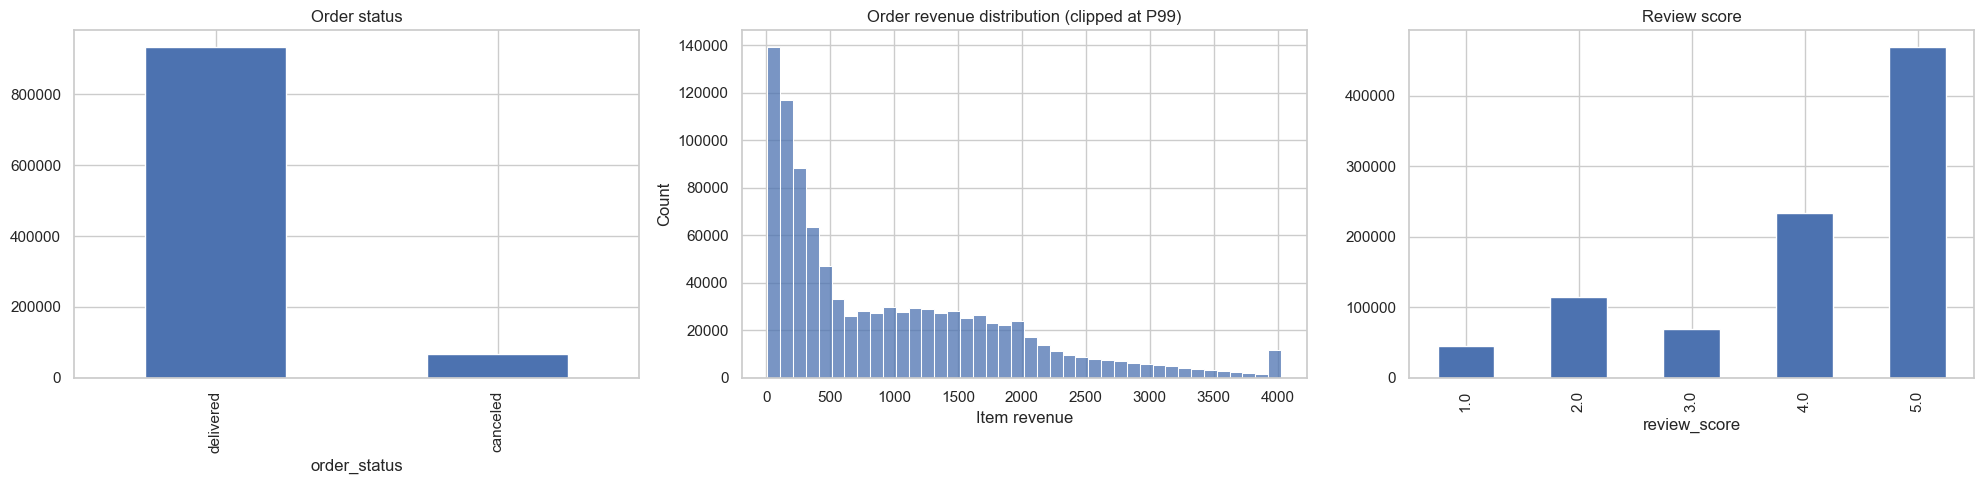

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
order_level['order_status'].value_counts().plot(kind='bar', ax=axes[0], title='Order status')
sns.histplot(order_level['item_revenue'].clip(upper=order_level['item_revenue'].quantile(0.99)).dropna(), bins=40, ax=axes[1])
axes[1].set(title='Order revenue distribution (clipped at P99)', xlabel='Item revenue')
reviews['review_score'].value_counts().sort_index().plot(kind='bar', ax=axes[2], title='Review score')
plt.tight_layout()

display(items[['price_x', 'freight_value', 'discount_rate', 'cost']].describe(percentiles=[.01, .25, .5, .75, .95, .99]).T)

## Bivariate and multivariate analysis

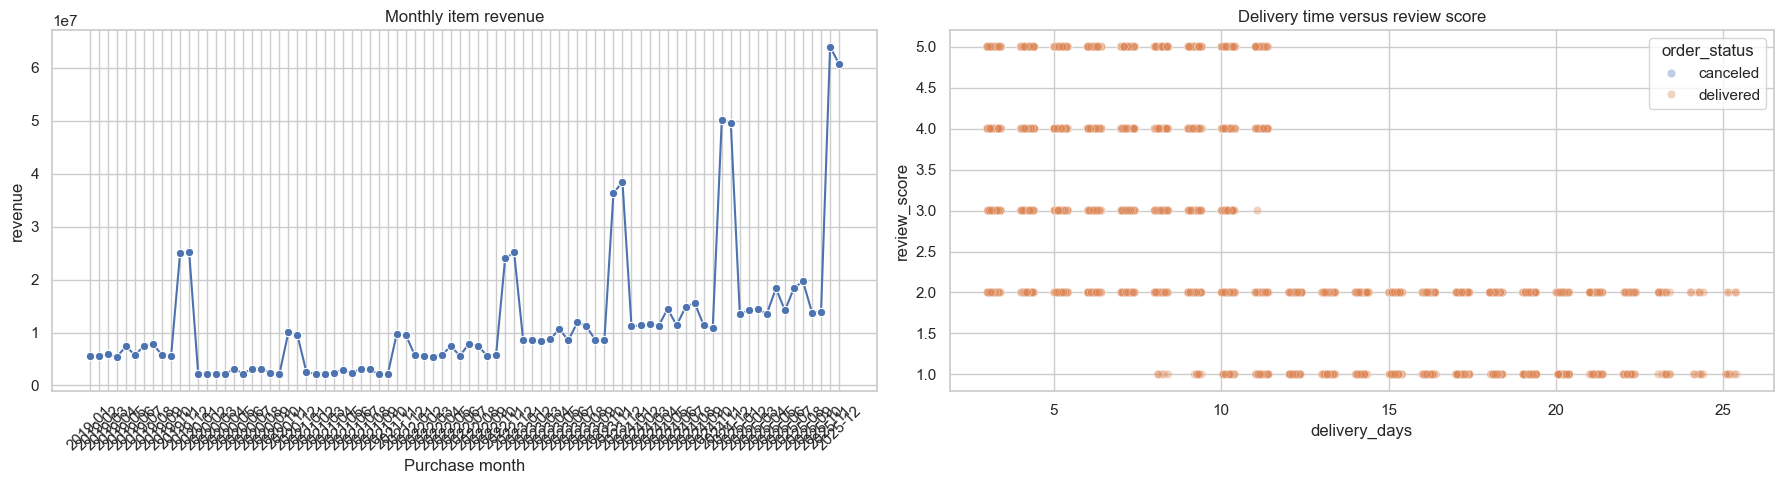

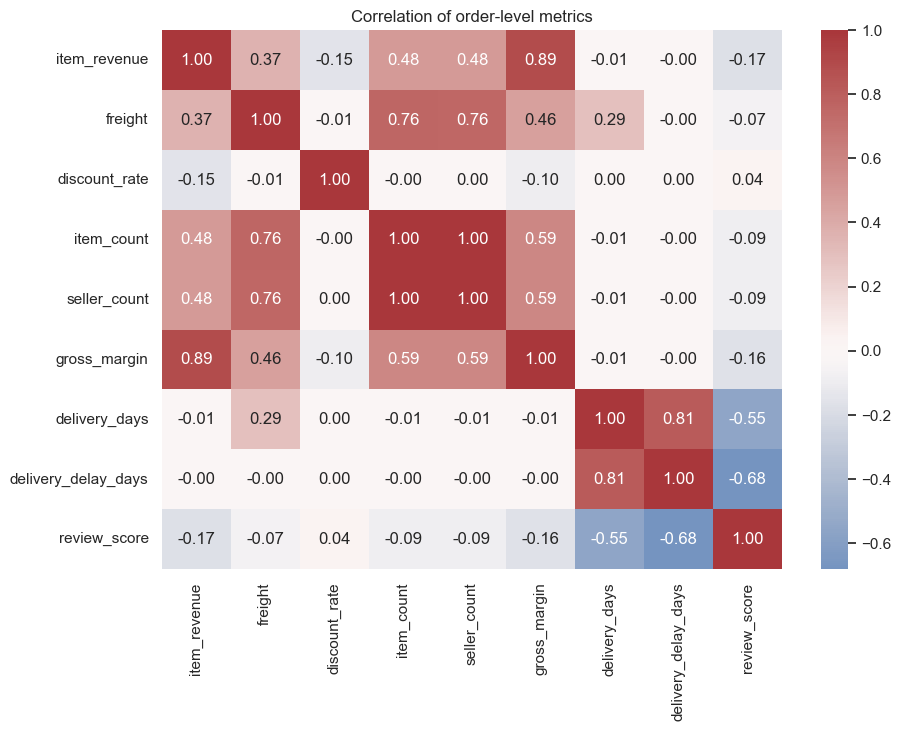

In [28]:
monthly = order_level.groupby('purchase_month', as_index=False).agg(
    orders=('order_id', 'nunique'), revenue=('item_revenue', 'sum'),
    avg_review=('review_score', 'mean'), late_rate=('delivery_delay_days', lambda x: 100 * x.gt(0).mean()),
)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.lineplot(data=monthly, x='purchase_month', y='revenue', marker='o', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45); axes[0].set(title='Monthly item revenue', xlabel='Purchase month')
sns.scatterplot(data=delivered.sample(min(10000, len(delivered)), random_state=42), x='delivery_days', y='review_score', hue='order_status', alpha=.35, ax=axes[1])
axes[1].set(title='Delivery time versus review score')
plt.tight_layout()

numeric_features = ['item_revenue', 'freight', 'discount_rate', 'item_count', 'seller_count', 'gross_margin', 'delivery_days', 'delivery_delay_days', 'review_score']
plt.figure(figsize=(10, 7))
sns.heatmap(order_level[numeric_features].corr(), cmap='vlag', center=0, annot=True, fmt='.2f')
plt.title('Correlation of order-level metrics')
plt.show()

## Order lifecycle analysis

,order_status,orders,avg_delivery_days,avg_approval_hours,avg_review
1,delivered,933748,7.78,5.08,4.03
0,canceled,66252,NaN,5.08,NaN


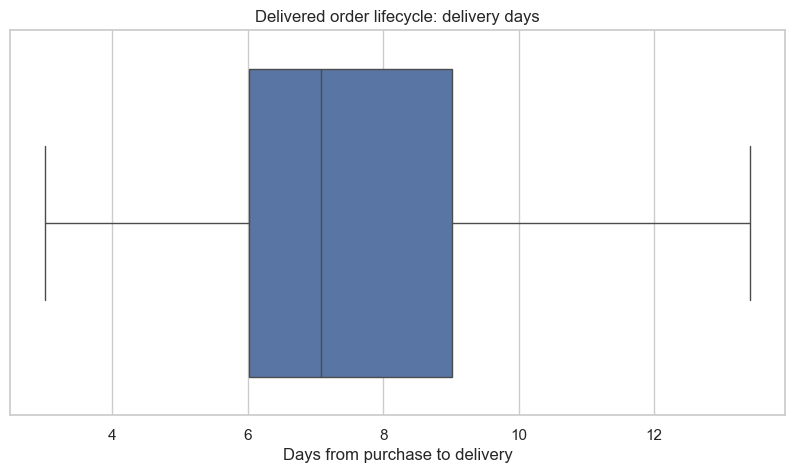

In [29]:
lifecycle = order_level.groupby('order_status', as_index=False).agg(
    orders=('order_id', 'nunique'), avg_delivery_days=('delivery_days', 'mean'),
    avg_approval_hours=('approval_hours', 'mean'), avg_review=('review_score', 'mean'),
).sort_values('orders', ascending=False)
display(lifecycle)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=delivered, x='delivery_days', showfliers=False, ax=ax)
ax.set(title='Delivered order lifecycle: delivery days', xlabel='Days from purchase to delivery')
plt.show()

## Customer behavior

In [30]:
customer_summary = order_level.groupby('customer_unique_id', as_index=False).agg(
    orders=('order_id', 'nunique'), spend=('item_revenue', 'sum'),
    average_review=('review_score', 'mean'), state=('customer_state', 'first'), segment=('customer_segment', 'first'),
)
customer_summary['repeat_customer'] = customer_summary['orders'].gt(1)
segment_summary = customer_summary.groupby('segment', as_index=False).agg(customers=('customer_unique_id', 'nunique'), orders=('orders', 'sum'), revenue=('spend', 'sum'), avg_spend=('spend', 'mean'))
display(segment_summary.sort_values('revenue', ascending=False))
print(f'Repeat-customer rate: {100 * customer_summary.repeat_customer.mean():.2f}%')
display(customer_summary.sort_values('spend', ascending=False).head(10))

,segment,customers,orders,revenue,avg_spend
0,Consumer,195831,700676,"626,726,400.00","3,200.34"
2,VIP,27811,99784,"178,252,928.00","6,409.44"
1,Corporate,55557,199540,"178,159,760.00","3,206.79"


Repeat-customer rate: 84.06%


,customer_unique_id,orders,spend,average_review,state,segment,repeat_customer
72364,427b8657-bd91-470a-8384-09709a2a0603,10,"33,062.53",4.00,IL,VIP,True
189657,ade4c17d-4ab5-485b-990a-5193672e9e6f,14,"31,997.58",3.92,TX,VIP,True
98811,5a99ee37-14a8-4d8a-9340-ad9604036135,13,"31,595.58",3.92,FL,VIP,True
150037,89a62c0c-1e4d-40df-90d0-f3402677b3b0,12,"31,575.72",3.73,WA,VIP,True
83047,4c47609f-80e7-4f7a-8937-1bc67a78b151,15,"30,808.60",3.50,CA,VIP,True
139026,7f625dd7-ca92-40ef-8cca-ef3624df4d4d,13,"30,449.16",3.27,CA,VIP,True
264444,f2770807-a02d-428e-810b-60824b4c86f2,13,"30,139.20",3.20,NY,VIP,True
184329,a9053682-5d14-4382-b9d0-24a0059bcb7c,12,"29,943.94",4.17,GA,VIP,True
66732,3d5062e6-87ef-4fe3-a6c5-c260e651ebd1,16,"29,780.35",4.07,FL,VIP,True
252069,e74b765f-a073-4201-a6e9-c1b07f76bf0a,12,"29,611.12",3.58,NY,VIP,True


## Product behavior and seller analysis

In [31]:
# ==========================================================
# Product-Level Summary
# ==========================================================

product_summary = (
    items.groupby(
        [
            "product_category_name",
            "product_id",
        ]
    )
    .agg(
        units=("order_item_id", "nunique"),
        revenue=("price_x", "sum"),
        cost=("cost", "sum"),
    )
    .reset_index()
)

product_summary["margin"] = (
    product_summary["revenue"]
    - product_summary["cost"]
)


# ==========================================================
# Category-Level Summary
# ==========================================================

category_summary = (
    items.groupby(
        "product_category_name",
        as_index=False,
    )
    .agg(
        units=("order_item_id", "nunique"),
        revenue=("price_x", "sum"),
        cost=("cost", "sum"),
    )
)

category_summary["margin"] = (
    category_summary["revenue"]
    - category_summary["cost"]
)

display(
    category_summary
    .sort_values(
        by="revenue",
        ascending=False,
    )
    .head(15)
)


# ==========================================================
# Seller-Level Summary
# ==========================================================

seller_summary = (
    items.groupby(
        "seller_id",
        as_index=False,
    )
    .agg(
        orders=("order_id", "nunique"),
        units=("order_item_id", "nunique"),
        revenue=("price_x", "sum"),
        cost=("cost", "sum"),
        state=("seller_state", "first"),
    )
)

seller_summary["margin"] = (
    seller_summary["revenue"]
    - seller_summary["cost"]
)

display(
    seller_summary
    .sort_values(
        by="revenue",
        ascending=False,
    )
    .head(10)
)

,product_category_name,units,revenue,cost,margin
2,electronics,6,"732,775,360.00","599,382,848.00","133,392,512.00"
4,furniture,6,"109,091,376.00","64,738,236.00","44,353,140.00"
3,fashion,6,"67,821,400.00","25,453,618.00","42,367,784.00"
5,home_goods,6,"33,883,172.00","17,201,448.00","16,681,724.00"
0,auto,6,"21,224,506.00","15,775,132.00","5,449,374.00"
6,toys,6,"12,588,102.00","5,628,544.00","6,959,558.00"
1,books,6,"5,755,156.50","3,461,708.75","2,293,447.75"


,seller_id,orders,units,revenue,cost,state,margin
431,db2a9dd9-bd20-430f-b133-628eac4f030e,4486,6,"2,106,255.00","1,578,676.12",NY,"527,578.88"
375,c0e29887-4950-4a94-9483-b4f0cf5c5bdc,4420,6,"2,099,601.25","1,571,362.00",NY,"528,239.25"
258,8261440c-a848-4521-a424-76a4e201368c,4593,6,"2,082,226.62","1,546,252.62",NY,"535,974.00"
175,59b0c0b4-2716-4581-b3f0-5dea54eef11e,4347,6,"2,080,831.88","1,559,890.50",TX,"520,941.38"
408,cff34287-7476-43ce-a1de-aa51bbb9c1c7,4469,6,"2,070,416.38","1,548,867.62",IL,"521,548.75"
148,4bc06d3b-da05-4bd7-b130-74665bdd4df2,4486,6,"2,067,520.00","1,544,633.62",PA,"522,886.38"
3,00c6e54e-1372-4d16-b4ac-94bd27aedbbb,4443,6,"2,065,393.50","1,544,672.00",CA,"520,721.50"
284,94eeadda-3ba2-49bd-abc6-9ddc520439b6,4486,6,"2,065,385.38","1,543,598.00",IL,"521,787.38"
342,afd0dacb-435d-4741-9b8f-8a126d5621d2,4474,6,"2,064,186.12","1,543,246.50",TX,"520,939.62"
93,2cc654c6-343d-46ec-bb72-eecc80c7dbe4,4521,6,"2,061,936.00","1,535,381.50",FL,"526,554.50"


## Payment analysis

,payment_type,transactions,orders,payment_value,avg_payment,avg_installments,payment_share_pct
3,credit_card,536416,512209,"620,220,672.00","1,156.23",6.41,50.75
5,paypal,181278,174725,"193,706,864.00","1,068.56",1.00,15.85
0,apple_pay,92114,92114,"118,802,888.00","1,289.74",1.00,9.72
1,bank_transfer,96766,96766,"94,242,928.00",973.93,1.00,7.71
6,voucher,123150,119465,"91,807,304.00",745.49,1.00,7.51
4,debit_card,91034,91034,"88,510,936.00",972.28,6.34,7.24
2,boleto,28613,28613,"14,892,989.00",520.50,1.00,1.22


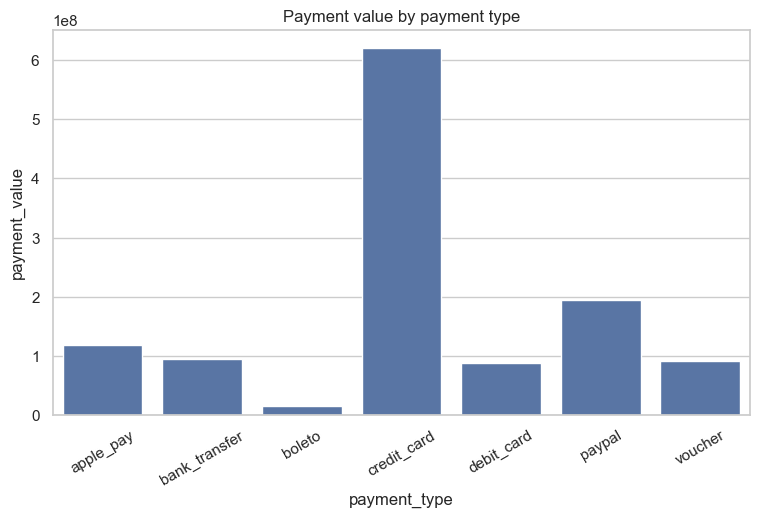

In [32]:
payment_analysis = payments.groupby('payment_type', as_index=False).agg(
    transactions=('payment_sequential', 'count'), orders=('order_id', 'nunique'),
    payment_value=('payment_value', 'sum'), avg_payment=('payment_value', 'mean'),
    avg_installments=('payment_installments', 'mean'),
)
payment_analysis['payment_share_pct'] = 100 * payment_analysis['payment_value'] / payment_analysis['payment_value'].sum()
display(payment_analysis.sort_values('payment_value', ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(data=payment_analysis.sort_values('payment_value', ascending=False), x='payment_type', y='payment_value')
plt.title('Payment value by payment type'); plt.xticks(rotation=30); plt.show()

## Review analysis

In [33]:
review_analysis = order_level.groupby('order_status', as_index=False).agg(
    reviewed_orders=('review_score', 'count'), avg_review=('review_score', 'mean'),
    median_delivery_days=('delivery_days', 'median'),
)
display(review_analysis.sort_values('avg_review'))

review_timing = reviews.dropna(subset=['review_creation_date', 'review_answer_timestamp']).copy()
review_timing['response_hours'] = (review_timing['review_answer_timestamp'] - review_timing['review_creation_date']).dt.total_seconds() / 3600
display(review_timing[['review_score', 'response_hours']].groupby('review_score').agg(['count', 'median', 'mean']))

,order_status,reviewed_orders,avg_review,median_delivery_days
1,delivered,933748,4.03,7.09
0,canceled,0,NaN,NaN


response_hours            
                      count median mean
review_score                           
1.00                  45808   2.00 2.00
2.00                 115300   2.00 2.00
3.00                  68823   2.00 2.00
4.00                 234499   2.00 2.00
5.00                 469318   2.00 2.00

## Business insights

Use this evidence table to identify the highest-value operational opportunities. Interpret results in context of the granular master-data construction and investigate unusually large values before acting on them.

In [34]:
state_insights = order_level.groupby('customer_state', as_index=False).agg(
    orders=('order_id', 'nunique'), revenue=('item_revenue', 'sum'), avg_review=('review_score', 'mean'),
    late_delivery_rate=('delivery_delay_days', lambda x: 100 * x.gt(0).mean()),
).sort_values('revenue', ascending=False)
display(state_insights.head(15))

insights = pd.DataFrame({
    'metric': ['Revenue concentration: top 10 sellers', 'Late-delivery rate', 'Low-score reviews (≤2)', 'Repeat-customer rate'],
    'value': [
        100 * seller_summary.nlargest(10, 'revenue')['revenue'].sum() / seller_summary['revenue'].sum(),
        100 * delivered['delivery_delay_days'].gt(0).mean(),
        100 * reviews['review_score'].le(2).mean(),
        100 * customer_summary['repeat_customer'].mean(),
    ],
    'unit': ['%', '%', '%', '%'],
})
display(insights.style.format({'value': '{:,.2f}'}))

,customer_state,orders,revenue,avg_review,late_delivery_rate
1,CA,251542,"247,228,880.00",4.03,9.22
8,TX,189675,"186,544,128.00",4.04,9.14
3,FL,138146,"135,884,432.00",4.04,9.20
6,NY,125554,"123,782,824.00",4.03,9.18
7,PA,84583,"83,176,600.00",4.03,9.23
5,IL,83255,"81,754,008.00",4.04,9.16
4,GA,63338,"62,421,348.00",4.03,9.36
2,CO,21664,"20,968,884.00",4.04,9.32
9,WA,21335,"20,845,806.00",4.05,9.21
0,AZ,20908,"20,532,178.00",4.04,9.22


,metric,value,unit
0,Revenue concentration: top 10 sellers,2.11,%
1,Late-delivery rate,9.86,%
2,Low-score reviews (≤2),17.25,%
3,Repeat-customer rate,84.06,%


In [36]:
PROCESSED_DATA = Path("../data/processed")
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

# Save the master dataset
master_df.to_parquet(
    PROCESSED_DATA / "master_df.parquet",
    index=False
)

print("✅ master_df saved successfully!")
print(f"📁 Location: {PROCESSED_DATA / 'master_df.parquet'}")
print(f"📊 Shape: {master_df.shape}")

✅ master_df saved successfully!
📁 Location: ..\data\processed\master_df.parquet
📊 Shape: (2530433, 49)


# EDA Summary

## Overview

The cleaned and integrated `master_df` was reconstructed into four analytical tables: **Orders**, **Items**, **Payments**, and **Reviews**, enabling order-level business analysis while avoiding duplicate records introduced during table joins. An aggregated `order_level` dataset was created by combining order, revenue, payment, and review information and deriving additional business metrics such as **gross margin**, **delivery duration**, **delivery delay**, **approval time**, **purchase month**, and **purchase weekday**.

The analytical dataset consists of:

- **1,000,000 Orders**
- **2,199,819 Order Items**
- **1,149,371 Payment Records**
- **933,748 Reviews**

---

# Key Business KPIs

The business processed **1 million orders** from **279,199 unique customers**, achieving a **93.37% delivery success rate**. The platform generated a **Gross Merchandise Value (GMV) of 983.14 million** and received **1.22 billion** in total customer payments.

Key performance indicators include:

- Average Order Value (AOV): **983.14**
- Average Freight Cost: **239.05**
- Gross Margin: **251.50 million**
- Average Review Score: **4.03 / 5**
- Median Delivery Time: **7.09 days**
- Late Delivery Rate: **9.86%**

Overall, these KPIs indicate a healthy business with strong order fulfillment performance and positive customer satisfaction.

---

# Univariate Analysis

The distribution analysis highlights the following observations:

- Most orders were successfully **delivered**, with cancelled orders accounting for only a small proportion of total orders.
- Item revenue is **right-skewed**, indicating that most products are low to medium priced while a small number of premium products contribute significantly to revenue.
- Review scores are heavily concentrated at **5 stars**, followed by **4 stars**, reflecting generally positive customer feedback.
- Product prices and freight charges exhibit moderate variability, while discount rates remain relatively low across transactions.
- Product costs follow a similar distribution to selling prices, supporting healthy gross margins.

---

# Bivariate & Multivariate Analysis

Several meaningful relationships were identified:

- Gross margin shows a **strong positive correlation (0.89)** with item revenue.
- Freight cost has a moderate positive relationship with revenue and item count.
- Delivery time and delivery delay are strongly correlated (**0.81**).
- Review score has a **negative correlation** with delivery duration (**-0.55**) and delivery delay (**-0.68**), indicating that customers tend to give lower ratings when deliveries take longer or arrive later than expected.
- Discount rate has minimal influence on other business metrics.

These findings suggest that operational efficiency, particularly delivery performance, has a direct impact on customer satisfaction.

---

# Order Lifecycle Analysis

Analysis of the order lifecycle shows:

- **933,748** orders were successfully delivered.
- **66,252** orders were cancelled.
- Delivered orders required an average of **7.78 days** for completion.
- Order approval occurred quickly, averaging approximately **5.08 hours** after purchase.
- Delivered orders achieved an average review score of **4.03**, while cancelled orders naturally contain no review information.

---

# Product Performance

Product category analysis indicates that:

- **Electronics** is the highest-performing category in terms of revenue and gross margin.
- **Furniture** and **Fashion** are the next largest revenue contributors.
- Categories such as **Books**, **Auto**, and **Toys** generate comparatively lower sales volumes.
- Electronics alone contributes the majority of platform revenue, making it the most strategically important category.

---

# Seller Performance

Seller analysis reveals that revenue is well distributed among the leading sellers.

The highest-performing sellers each generated approximately **2 million** in revenue while maintaining gross margins exceeding **500,000**. Top sellers are distributed across multiple states including **New York, Texas, California, Illinois, Pennsylvania, and Florida**, indicating a geographically diverse seller network.

---

# Payment Analysis

Customer payments are dominated by digital payment methods.

Key observations include:

- **Credit Card** payments account for **50.75%** of total payment value.
- **PayPal** contributes **15.85%**.
- **Apple Pay**, **Bank Transfer**, **Voucher**, and **Debit Card** each contribute between **7–10%**.
- Credit card purchases typically involve the highest number of installment payments.

These results indicate a strong customer preference for flexible electronic payment methods.

---

# Customer Review Analysis

Customer satisfaction is generally high.

Key findings include:

- Average review score: **4.03 / 5**
- Most reviews are **5-star ratings**.
- Approximately **17.25%** of reviews have scores of **2 or below**.
- Review response time remains consistent across all review scores, averaging approximately **2 hours**, suggesting a standardized customer support process.

---

# Regional Performance

Revenue is concentrated in a few major states.

- **California** generates the highest revenue.
- **Texas**, **Florida**, **New York**, and **Pennsylvania** follow closely.
- Average review scores remain consistently around **4.0** across all states.
- Late delivery rates remain relatively stable at approximately **9–10%**, indicating consistent logistics performance across regions.

---

# Business Insights

The exploratory analysis provides several key business insights:

- High customer satisfaction is reflected by the predominance of **5-star reviews**.
- Delivery efficiency has a measurable impact on customer ratings.
- Electronics is the primary revenue and profit driver.
- Credit cards remain the preferred payment method.
- Revenue is diversified across sellers, with the top 10 sellers contributing only **2.11%** of total revenue.
- The platform maintains a strong **84.06% repeat customer rate**, indicating excellent customer retention.
- Although only **9.86%** of orders are delivered late, reducing delivery delays could further improve customer satisfaction and business performance.

---

# Next Steps

- Perform advanced customer segmentation using **RFM analysis**.
- Identify high-value customers through **Customer Lifetime Value (CLV)** analysis.
- Build product recommendation models using customer purchase history.
- Develop sales forecasting models for demand planning.
- Train churn prediction models using customer behavior and review data.
- Analyze delivery operations to reduce late deliveries and improve customer experience.
- Create interactive Power BI dashboards to monitor KPIs and business performance.